<a href="https://www.kaggle.com/code/sonawanelalitsunil/netflix-streaming-insights-ml-99-69?scriptVersionId=253920488" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/netflix-data/Netflix Dataset.csv


## Title:
Netflix Streaming Insights

## Description:
This dataset provides detailed information about Netflix’s content catalog, including movies and TV shows available on the platform. It includes attributes such as title, type (movie or TV show), director, cast, country of origin, date added, release year, rating, duration, genre, and a brief description.

The goal of this analysis is to explore trends in content availability, examine genre distribution, understand content ratings over time, and identify key contributors such as directors and actors. Through visualizations and machine learning, we can gain insights into how Netflix’s content strategy has evolved over the years and potentially predict user preferences or content success factors.



## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/netflix-data/Netflix Dataset.csv")

In [3]:
df.head()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
df.tail()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
7784,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7785,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7786,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7787,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7788,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7789 entries, 0 to 7788
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Show_Id       7789 non-null   object
 1   Category      7789 non-null   object
 2   Title         7789 non-null   object
 3   Director      5401 non-null   object
 4   Cast          7071 non-null   object
 5   Country       7282 non-null   object
 6   Release_Date  7779 non-null   object
 7   Rating        7782 non-null   object
 8   Duration      7789 non-null   object
 9   Type          7789 non-null   object
 10  Description   7789 non-null   object
dtypes: object(11)
memory usage: 669.5+ KB


In [6]:
df.describe()

,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
count,7789,7789,7789,5401,7071,7282,7779,7782,7789,7789,7789
unique,7787,2,7787,4050,6831,681,1565,14,216,492,7769
top,s6621,Movie,The Lost Okoroshi,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,2,5379,2,18,18,2556,118,2865,1608,334,3


In [7]:
df.dtypes

Show_Id         object
Category        object
Title           object
Director        object
Cast            object
Country         object
Release_Date    object
Rating          object
Duration        object
Type            object
Description     object
dtype: object

In [8]:
df.shape

(7789, 11)

In [9]:
df.isnull().sum()

Show_Id            0
Category           0
Title              0
Director        2388
Cast             718
Country          507
Release_Date      10
Rating             7
Duration           0
Type               0
Description        0
dtype: int64

In [10]:
df.duplicated().sum()

2

In [11]:
df.columns

Index(['Show_Id', 'Category', 'Title', 'Director', 'Cast', 'Country',
       'Release_Date', 'Rating', 'Duration', 'Type', 'Description'],
      dtype='object')

## Data visualizations

Text(0.5, 1.0, 'Content Category Distribution')

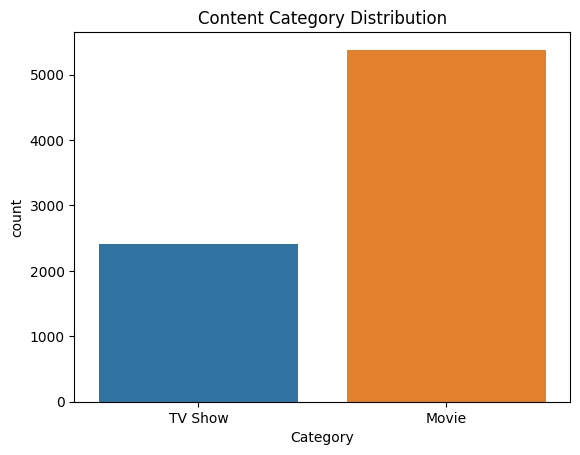

In [12]:
sns.countplot(data=df, x='Category')
plt.title('Content Category Distribution')


Text(0.5, 1.0, 'Top 10 Countries on Netflix')

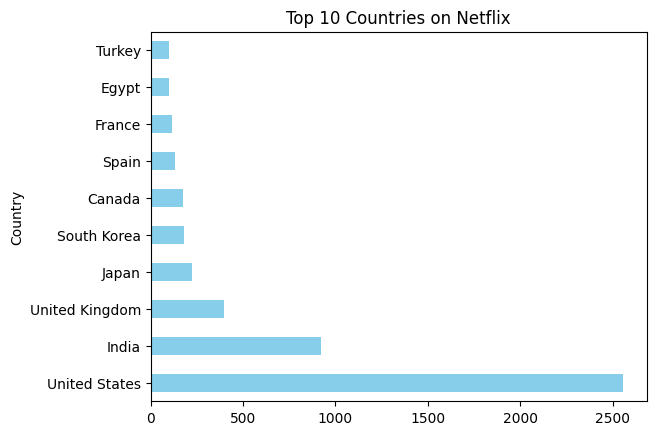

In [13]:
top_countries = df['Country'].value_counts().head(10)
top_countries.plot(kind='barh', color='skyblue')
plt.title('Top 10 Countries on Netflix')


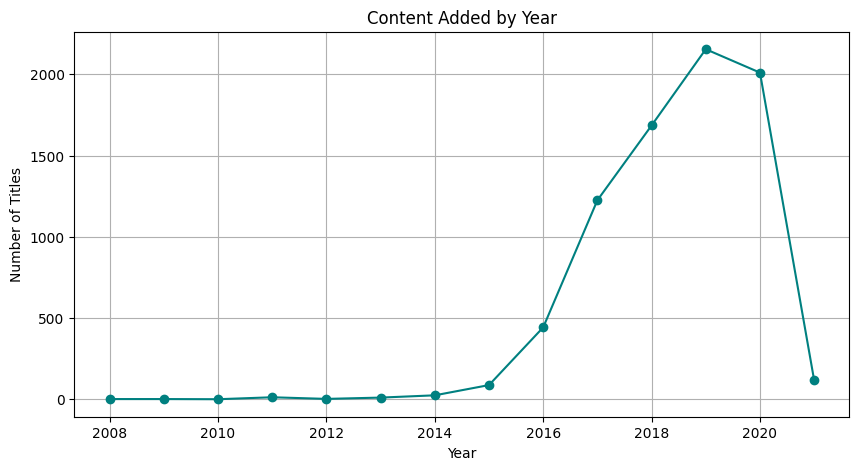

In [14]:
# Remove leading/trailing whitespace
df['Release_Date'] = df['Release_Date'].str.strip()

# Convert to datetime safely
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

# Extract year
df['Year_Added'] = df['Release_Date'].dt.year

# Plot content count by year
df['Year_Added'].value_counts().sort_index().plot(kind='line', marker='o', figsize=(10,5), color='teal')
plt.title('Content Added by Year')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'Distribution of Content Ratings')

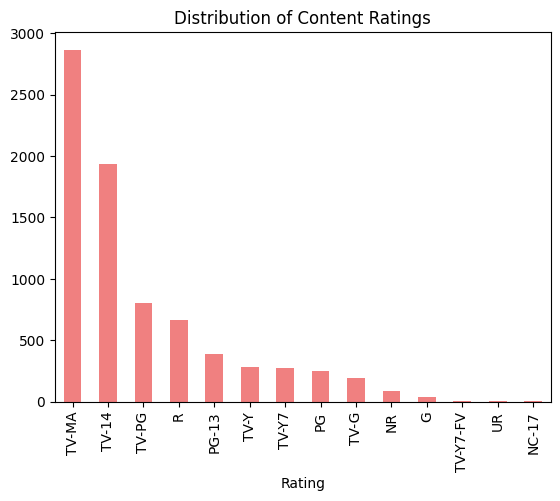

In [15]:
df['Rating'].value_counts().plot(kind='bar', color='lightcoral')
plt.title('Distribution of Content Ratings')


Text(0.5, 1.0, 'Distribution of Movie Durations')

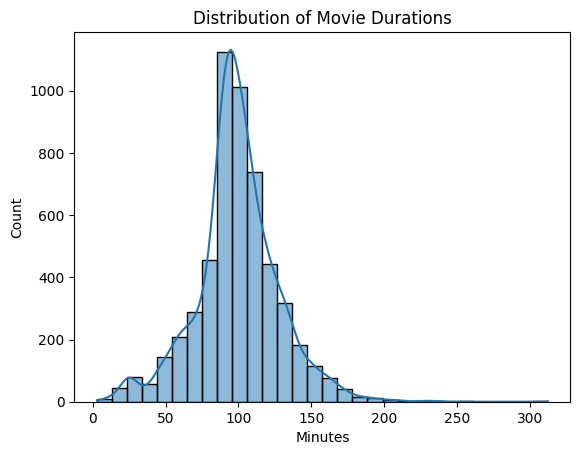

In [16]:
# Separate movies and shows
movies = df[df['Category'] == 'Movie']
tv_shows = df[df['Category'] == 'TV Show']

# Extract numeric duration
movies['Minutes'] = movies['Duration'].str.extract('(\d+)').astype(float)
sns.histplot(movies['Minutes'].dropna(), bins=30, kde=True)
plt.title('Distribution of Movie Durations')


Text(0.5, 1.0, 'Top 10 Content Types or Genres')

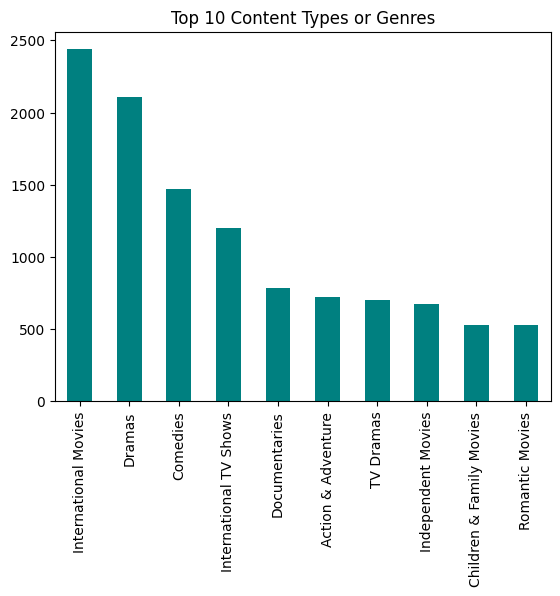

In [17]:
# (Optional) if you have a 'Genre' or 'Type' column split by commas
from collections import Counter
import itertools

# Example: count individual genres if `Type` or another column is like 'Action, Drama'
genres = df['Type'].dropna().str.split(', ')
all_genres = list(itertools.chain.from_iterable(genres))
genre_counts = pd.Series(Counter(all_genres)).sort_values(ascending=False).head(10)
genre_counts.plot(kind='bar', color='teal')
plt.title('Top 10 Content Types or Genres')


Text(0.5, 1.0, 'Top 10 Directors on Netflix')

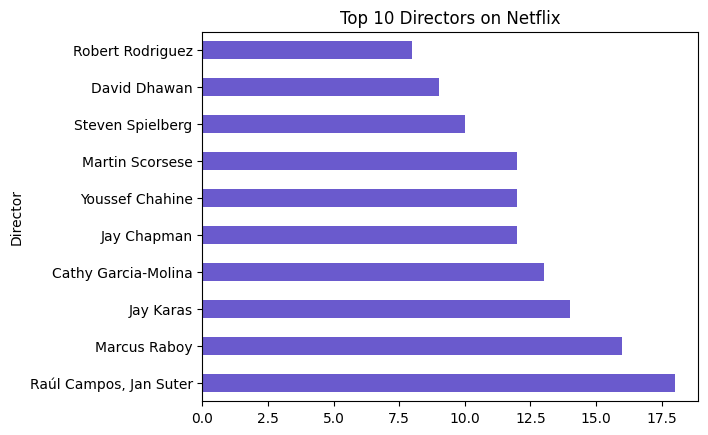

In [18]:
top_directors = df['Director'].value_counts().head(10)
top_directors.plot(kind='barh', color='slateblue')
plt.title('Top 10 Directors on Netflix')


Text(0.5, 1.0, 'Common Words in Descriptions')

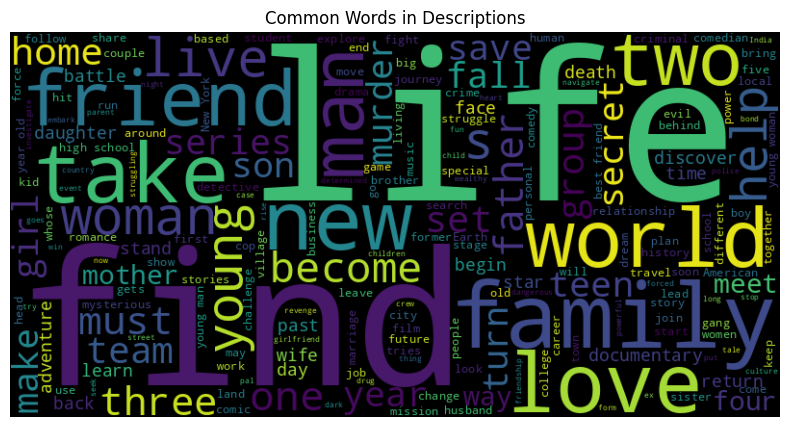

In [19]:
from wordcloud import WordCloud

text = ' '.join(df['Description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Common Words in Descriptions')


Text(0.5, 1.0, 'Top 10 Actors/Actresses on Netflix')

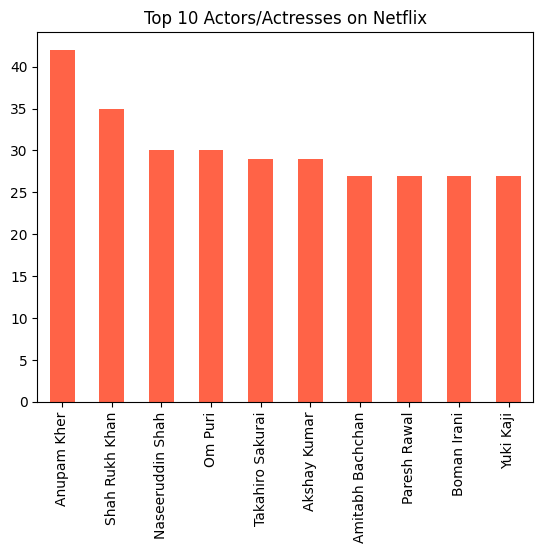

In [20]:
cast_series = df['Cast'].dropna().str.split(', ')
all_cast = list(itertools.chain.from_iterable(cast_series))
cast_counts = pd.Series(Counter(all_cast)).sort_values(ascending=False).head(10)
cast_counts.plot(kind='bar', color='tomato')
plt.title('Top 10 Actors/Actresses on Netflix')


## Predictive modeling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [22]:
# Drop rows with missing values
df.dropna(inplace=True)

# Convert Release_Date to string to avoid LabelEncoder error
df['Release_Date'] = df['Release_Date'].astype(str)

# Label Encoding for all columns
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Set Features and Target
X = df.drop("Category", axis=1)  # Features
y = df["Category"]              # Target

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train and evaluate
print("Model Accuracies (%):\n")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"{name}: {acc:.2f}%")

Model Accuracies (%):

Logistic Regression: 96.88%
Decision Tree: 99.58%
Random Forest: 99.69%
Naive Bayes: 96.88%
Support Vector Machine: 96.88%
K-Nearest Neighbors: 96.88%


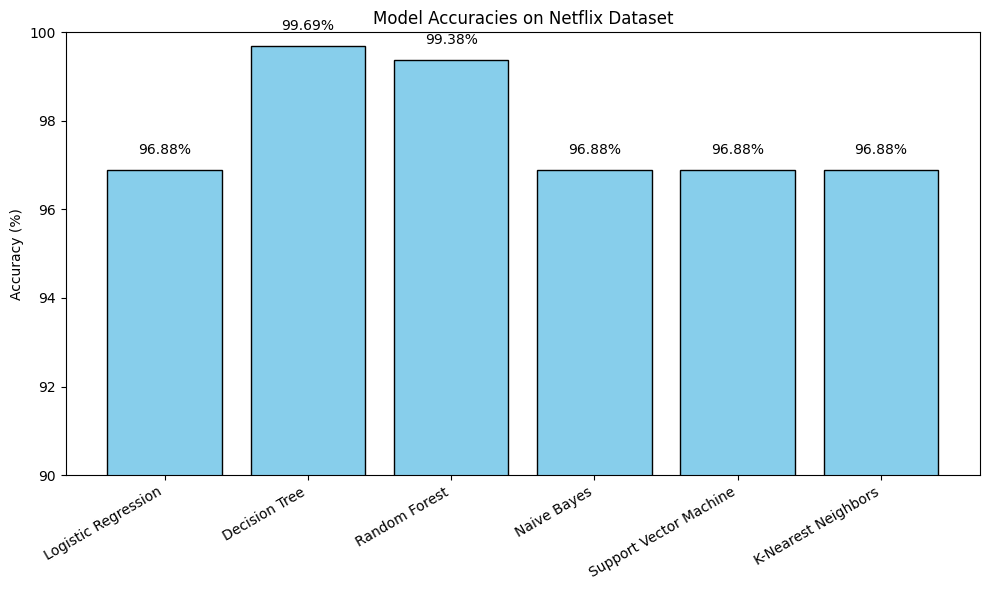

In [23]:
# Model accuracies
model_names = [
    "Logistic Regression", "Decision Tree", "Random Forest",
    "Naive Bayes", "Support Vector Machine", "K-Nearest Neighbors"
]
accuracies = [96.88, 99.69, 99.38, 96.88, 96.88, 96.88]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color='skyblue', edgecolor='black')
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracies on Netflix Dataset")
plt.ylim(90, 100)

# Add accuracy values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, f"{yval:.2f}%", ha='center', va='bottom')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Thank you..pls upvote!!!